# Stage 1A — DAVIS dataset loading and inspection

This notebook loads the existing `shapes_6dof` DAVIS recording through Tonic, validates event/APS/IMU/ground-truth structure and timestamp ranges, and saves compact metadata plus a range plot. It does **not** extract features, associate events, track, or synchronize streams.

Tonic converts timestamps to integer microseconds and independently subtracts the first timestamp of each stream. The shared x-axis below compares the reported numeric ranges only; it is **not** evidence that stream timestamps are aligned.

In [1]:
import sys
from pathlib import Path

project_root = next(
    (
        parent
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "src" / "davis_inspection.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root containing src/davis_inspection.py")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import Image, display

from src.davis_inspection import (
    DEFAULT_OUTPUT_DIR,
    DavisConfig,
    inspect_davis,
    load_davis,
    plot_timestamp_ranges,
    print_report,
    save_metadata,
)

config = DavisConfig()
recording = load_davis(config)
metadata = inspect_davis(recording, config)
print_report(metadata)

DAVIS recording: shapes_6dof
Events: 17,962,477
Image resolution: 240 x 180 px
APS frames: 1,356
events: [0, 59,735,406] microseconds
aps_frames: [0, 59,708,571] microseconds
imu: [0, 59,726,941] microseconds
ground_truth: [0, 59,720,426] microseconds
Timestamp interpretation: Tonic converts source seconds to integer microseconds and resets each stream's first timestamp independently to zero. Reported ranges are stream-relative and are not synchronized.


Metadata saved to: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/dataset_inspection/shapes_6dof_metadata.json
Timestamp range plot saved to: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/dataset_inspection/shapes_6dof_timestamp_ranges.png


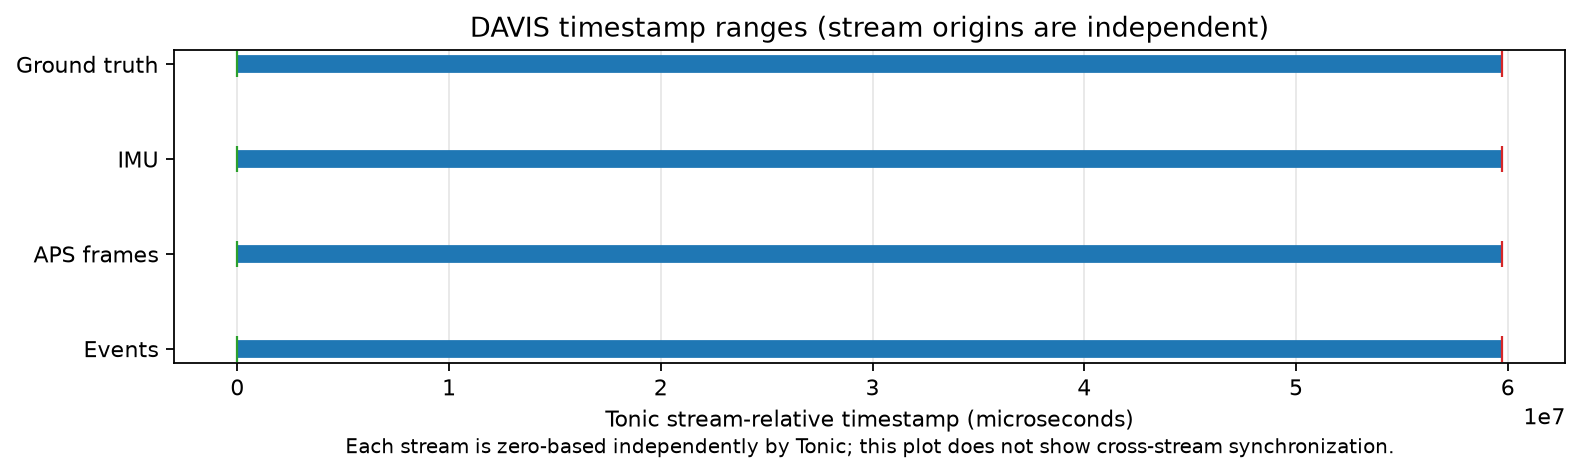

In [2]:
metadata_path = save_metadata(
    metadata, DEFAULT_OUTPUT_DIR / f"{config.recording}_metadata.json"
)
plot_path = plot_timestamp_ranges(
    metadata, DEFAULT_OUTPUT_DIR / f"{config.recording}_timestamp_ranges.png"
)
print(f"Metadata saved to: {metadata_path}")
print(f"Timestamp range plot saved to: {plot_path}")
display(Image(filename=str(plot_path)))

## Timestamp interpretation and limits

- The event record fields are `(t, x, y, p)`; coordinates are checked against the APS frame dimensions and polarity is checked to be binary.
- Event, APS, IMU, and target timestamp arrays are checked for non-empty integer-microsecond values and monotonic order. Missing IMU or target data is reported as unavailable.
- Timestamp ranges retain Tonic's per-stream zero origins. No offset estimation, cross-stream matching, resampling, clock correction, or calibration is performed.
- The JSON output stores configuration and summary metadata only; the loaded event/image arrays are not copied into output files.